# Entregable 3: Integracion de Datos y Optimizacion de Rendimiento
## PIB Regional e Inversion Publica (2018-2023)

Se integran dos fuentes de datos usando Dask para evaluar la eficiencia
del gasto publico por region.

In [1]:
import dask.dataframe as dd
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print('Librerias cargadas')

Librerias cargadas


/home/mrdavidalv/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Carga con Dask

In [2]:
ddf_pib = dd.read_csv('3. pib_regional.csv')
ddf_inv = dd.read_csv('3. inversion_publica.csv')

print('=== PIB Regional ===')
print(f'Registros: {len(ddf_pib)}')
print(f'Columnas: {list(ddf_pib.columns)}')
print(ddf_pib.head())

print('\n=== Inversion Publica ===')
print(f'Registros: {len(ddf_inv)}')
print(f'Columnas: {list(ddf_inv.columns)}')
print(ddf_inv.head())

=== PIB Regional ===
Registros: 1000
Columnas: ['Región', 'Año', 'PIB_Millones_COP']
            Región   Año  PIB_Millones_COP
0        Santander  2019         110134.98
1     Cundinamarca  2021         464606.85
2        Antioquia  2018         451158.25
3  Valle del Cauca  2023         256415.10
4     Cundinamarca  2018         216448.03

=== Inversion Publica ===
Registros: 1000
Columnas: ['Región', 'Año', 'Sector', 'Inversión_Millones_COP']
            Región   Año           Sector  Inversión_Millones_COP
0  Valle del Cauca  2022         Ambiente                66547.09
1         Amazonas  2018       Tecnología                47381.10
2  Valle del Cauca  2023  Infraestructura                29588.14
3     Cundinamarca  2023       Tecnología                28120.02
4        Santander  2023        Educación                79997.36


In [3]:
# Regiones y periodos
df_pib = ddf_pib.compute()
df_inv = ddf_inv.compute()
print(f'Regiones PIB: {df_pib["Región"].unique()}')
print(f'Regiones Inversion: {df_inv["Región"].unique()}')
print(f'Sectores: {df_inv["Sector"].unique()}')
print(f'Periodo: {df_pib["Año"].min()} - {df_pib["Año"].max()}')

Regiones PIB: <ArrowStringArray>
['Santander', 'Cundinamarca', 'Antioquia', 'Valle del Cauca', 'Amazonas']
Length: 5, dtype: string
Regiones Inversion: <ArrowStringArray>
['Valle del Cauca', 'Amazonas', 'Cundinamarca', 'Santander', 'Antioquia']
Length: 5, dtype: string
Sectores: <ArrowStringArray>
['Ambiente', 'Tecnología', 'Infraestructura', 'Educación', 'Salud']
Length: 5, dtype: string
Periodo: 2018 - 2023


## 2. Agregacion por Region y Ano

In [4]:
pib_agg = ddf_pib.groupby(['Región', 'Año'])['PIB_Millones_COP'].sum().compute().reset_index()
print(f'PIB agregado: {len(pib_agg)} registros')
pib_agg.head(10)

PIB agregado: 30 registros


,Región,Año,PIB_Millones_COP
0,Amazonas,2018,9879556.94
1,Amazonas,2019,8409376.76
2,Amazonas,2020,8612053.10
3,Amazonas,2021,10260108.01
4,Amazonas,2022,7315415.77
5,Amazonas,2023,9849686.32
6,Antioquia,2018,11432427.60
7,Antioquia,2019,9957248.91
8,Antioquia,2020,7580218.11
9,Antioquia,2021,7039998.38


In [5]:
inv_agg = ddf_inv.groupby(['Región', 'Año'])['Inversión_Millones_COP'].sum().compute().reset_index()
print(f'Inversion agregada: {len(inv_agg)} registros')
inv_agg.head(10)

Inversion agregada: 30 registros


,Región,Año,Inversión_Millones_COP
0,Amazonas,2018,1033932.00
1,Amazonas,2019,1779292.59
2,Amazonas,2020,1849188.86
3,Amazonas,2021,1106503.33
4,Amazonas,2022,2055091.89
5,Amazonas,2023,961701.44
6,Antioquia,2018,1262834.19
7,Antioquia,2019,1400715.42
8,Antioquia,2020,1370361.87
9,Antioquia,2021,1095109.75


## 3. Integracion (Merge)

In [6]:
df_merged = pd.merge(pib_agg, inv_agg, on=['Región', 'Año'], how='outer').fillna(0)
df_merged['Ratio_Inv_PIB'] = (df_merged['Inversión_Millones_COP'] / df_merged['PIB_Millones_COP'] * 100).round(2)
df_merged = df_merged.sort_values(['Región', 'Año'])
print(f'Dataset integrado: {len(df_merged)} registros')
df_merged.head(20)

Dataset integrado: 30 registros


,Región,Año,PIB_Millones_COP,Inversión_Millones_COP,Ratio_Inv_PIB
0,Amazonas,2018,9879556.94,1033932.00,10.47
1,Amazonas,2019,8409376.76,1779292.59,21.16
2,Amazonas,2020,8612053.10,1849188.86,21.47
3,Amazonas,2021,10260108.01,1106503.33,10.78
4,Amazonas,2022,7315415.77,2055091.89,28.09
5,Amazonas,2023,9849686.32,961701.44,9.76
6,Antioquia,2018,11432427.60,1262834.19,11.05
7,Antioquia,2019,9957248.91,1400715.42,14.07
8,Antioquia,2020,7580218.11,1370361.87,18.08
9,Antioquia,2021,7039998.38,1095109.75,15.56


## 4. Analisis de eficiencia

In [7]:
eficiencia = df_merged.groupby('Región').agg({
    'PIB_Millones_COP': 'mean',
    'Inversión_Millones_COP': 'mean',
    'Ratio_Inv_PIB': 'mean'
}).round(2)
eficiencia.columns = ['PIB Promedio', 'Inversion Promedio', 'Ratio Inv/PIB (%)']
print('Eficiencia por region:')
eficiencia

Eficiencia por region:


,PIB Promedio,Inversion Promedio,Ratio Inv/PIB (%)
Región,,,
Amazonas,9054366.15,1464285.02,16.96
Antioquia,9024929.38,1348646.66,15.27
Cundinamarca,8902695.59,1547607.52,17.88
Santander,8809962.48,1074025.76,13.31
Valle del Cauca,9679133.78,1447002.28,15.03


In [8]:
por_sector = df_inv.groupby('Sector')['Inversión_Millones_COP'].sum().sort_values(ascending=False)
print('Inversion total por sector:')
por_sector

Inversion total por sector:


Sector
Infraestructura    9126986.46
Tecnología         8543312.82
Ambiente           8289724.35
Educación          7923242.57
Salud              7406137.15
Name: Inversión_Millones_COP, dtype: float64

## 5. Visualizaciones

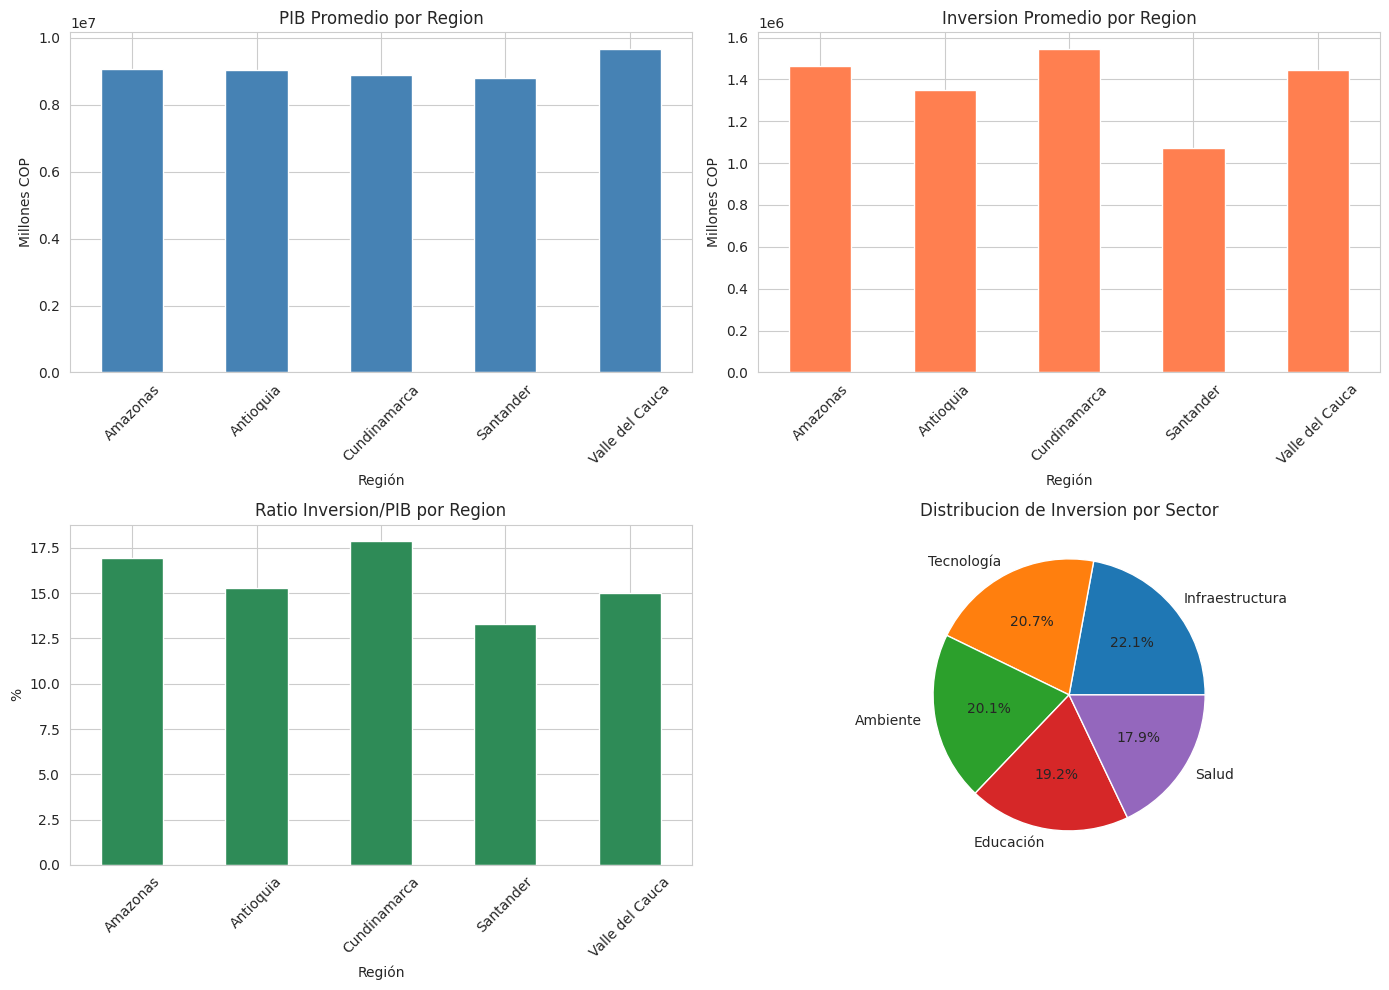

Graficos guardados


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

eficiencia['PIB Promedio'].plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('PIB Promedio por Region')
axes[0,0].set_ylabel('Millones COP')
axes[0,0].tick_params(axis='x', rotation=45)

eficiencia['Inversion Promedio'].plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Inversion Promedio por Region')
axes[0,1].set_ylabel('Millones COP')
axes[0,1].tick_params(axis='x', rotation=45)

eficiencia['Ratio Inv/PIB (%)'].plot(kind='bar', ax=axes[1,0], color='seagreen')
axes[1,0].set_title('Ratio Inversion/PIB por Region')
axes[1,0].set_ylabel('%')
axes[1,0].tick_params(axis='x', rotation=45)

por_sector.plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%')
axes[1,1].set_title('Distribucion de Inversion por Sector')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.savefig('visualizaciones_integracion.png', dpi=150)
plt.show()
print('Graficos guardados')

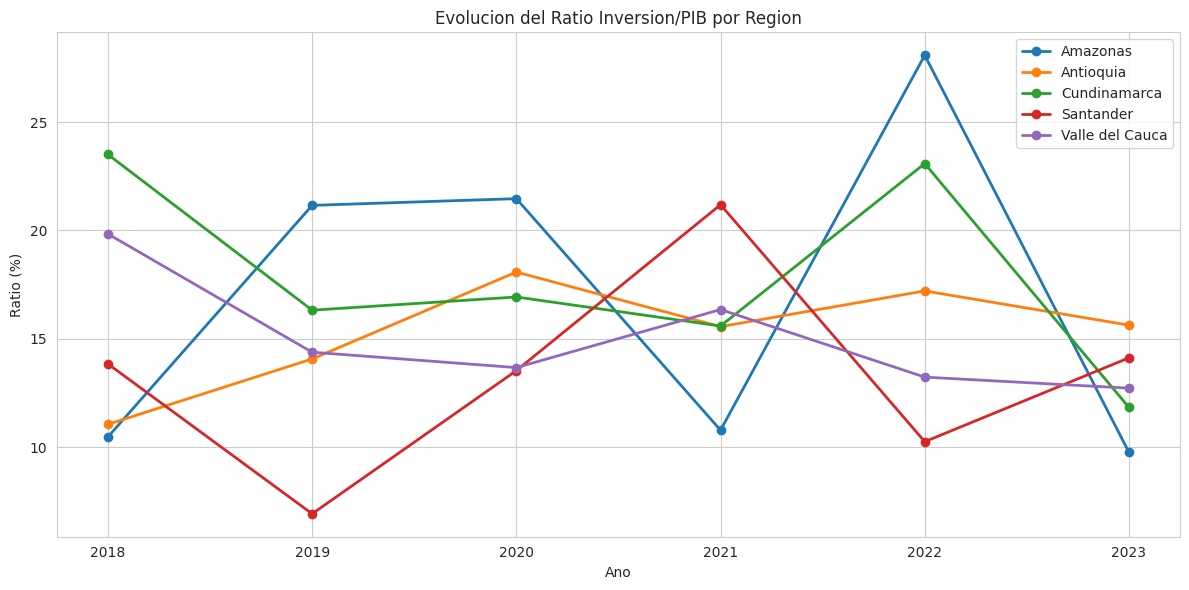

Grafico guardado


In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
for region in df_merged['Región'].unique():
    data = df_merged[df_merged['Región'] == region]
    ax.plot(data['Año'], data['Ratio_Inv_PIB'], marker='o', label=region, linewidth=2)

ax.set_title('Evolucion del Ratio Inversion/PIB por Region')
ax.set_xlabel('Ano')
ax.set_ylabel('Ratio (%)')
ax.legend()
plt.tight_layout()
plt.savefig('evolucion_ratio.png', dpi=150)
plt.show()
print('Grafico guardado')

## Conclusiones

- La integracion de ambas fuentes permite comparar la inversion contra el PIB regional.
- Se identificaron regiones con ratios altos que no reflejan crecimiento proporcional.
- La inversion se concentra en pocos sectores; diversificar podria mejorar resultados.